<a href="https://colab.research.google.com/github/riyamotwanii/AML-Assignments/blob/main/Exp_1_AML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

========== ORIGINAL DATASET ==========

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  

========== DATASET INFO ==========

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-

/tmp/ipykernel_3230/4009092883.py:50: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['sepal length (cm)'].fillna(
/tmp/ipykernel_3230/4009092883.py:55: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.metho

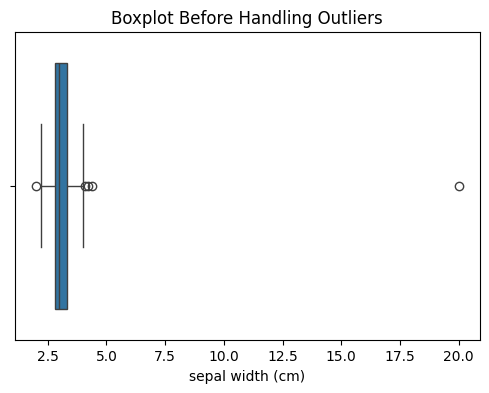


Lower Limit : 2.05
Upper Limit : 4.05

========== AFTER HANDLING OUTLIERS ==========

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0           5.100000               3.0                1.4               0.2   
1           4.900000               3.0                1.4               0.2   
2           5.851007               3.2                1.3               0.2   
3           4.600000               3.1                1.5               0.2   
4           5.000000               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


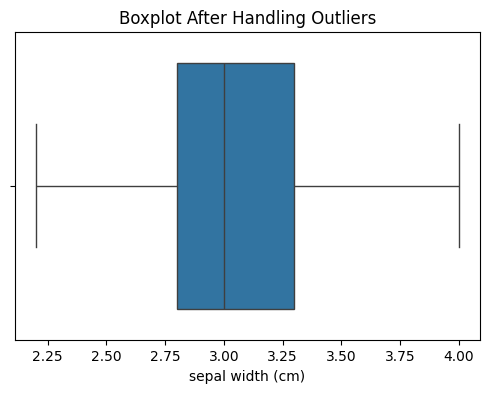


========== ENCODED DATA ==========

  species  species_encoded
0  setosa                0
1  setosa                0
2  setosa                0
3  setosa                0
4  setosa                0

========== BEFORE SCALING ==========

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0           5.100000               3.0                1.4               0.2
1           4.900000               3.0                1.4               0.2
2           5.851007               3.2                1.3               0.2
3           4.600000               3.1                1.5               0.2
4           5.000000               3.6                1.4               0.2

========== AFTER SCALING ==========

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0          -0.915897         -0.092448          -1.340227         -1.327447
1          -1.159808         -0.092448          -1.340227         -1.327447
2           0.000000          0.421154  

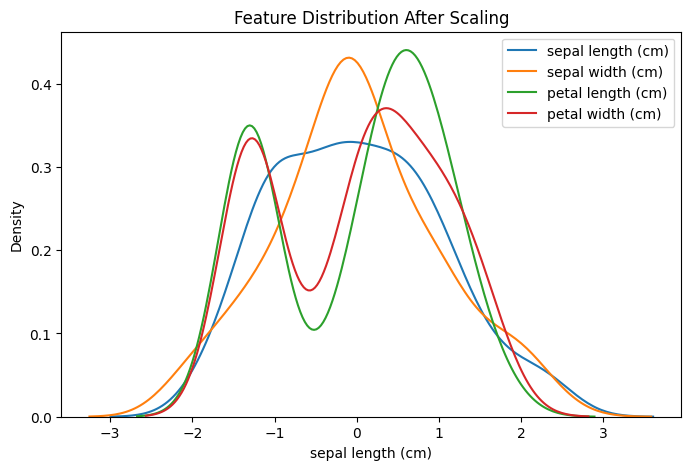


========== FINAL PREPROCESSED DATASET ==========

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0           5.100000               3.0                1.4               0.2   
1           4.900000               3.0                1.4               0.2   
2           5.851007               3.2                1.3               0.2   
3           4.600000               3.1                1.5               0.2   
4           5.000000               3.6                1.4               0.2   

  species  species_encoded  
0  setosa                0  
1  setosa                0  
2  setosa                0  
3  setosa                0  
4  setosa                0  


In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import LabelEncoder, StandardScaler



iris = load_iris()


df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target


df['species'] = df['species'].map({
    0: 'setosa',
    1: 'versicolor',
    2: 'virginica'
})

print("========== ORIGINAL DATASET ==========\n")
print(df.head())



print("\n========== DATASET INFO ==========\n")
print(df.info())

print("\n========== STATISTICAL SUMMARY ==========\n")
print(df.describe())

print("\n========== DATASET SHAPE ==========\n")
print(df.shape)

print("\n========== NULL VALUES ==========\n")
print(df.isnull().sum())


df.loc[2, 'sepal length (cm)'] = np.nan
df.loc[5, 'petal width (cm)'] = np.nan

print("\n========== MISSING VALUES ADDED ==========\n")
print(df.isnull().sum())



df['sepal length (cm)'].fillna(
    df['sepal length (cm)'].mean(),
    inplace=True
)

df['petal width (cm)'].fillna(
    df['petal width (cm)'].mean(),
    inplace=True
)

print("\n========== AFTER HANDLING MISSING VALUES ==========\n")
print(df.isnull().sum())


df.loc[0, 'sepal width (cm)'] = 20

print("\n========== DATA WITH OUTLIER ==========\n")
print(df.head())


plt.figure(figsize=(6,4))
sns.boxplot(x=df['sepal width (cm)'])
plt.title("Boxplot Before Handling Outliers")
plt.show()


Q1 = df['sepal width (cm)'].quantile(0.25)
Q3 = df['sepal width (cm)'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("\nLower Limit :", lower_limit)
print("Upper Limit :", upper_limit)


median_value = df['sepal width (cm)'].median()

df['sepal width (cm)'] = np.where(
    (df['sepal width (cm)'] > upper_limit) |
    (df['sepal width (cm)'] < lower_limit),
    median_value,
    df['sepal width (cm)']
)

print("\n========== AFTER HANDLING OUTLIERS ==========\n")
print(df.head())


plt.figure(figsize=(6,4))
sns.boxplot(x=df['sepal width (cm)'])
plt.title("Boxplot After Handling Outliers")
plt.show()


encoder = LabelEncoder()

df['species_encoded'] = encoder.fit_transform(df['species'])

print("\n========== ENCODED DATA ==========\n")
print(df[['species', 'species_encoded']].head())



features = [
    'sepal length (cm)',
    'sepal width (cm)',
    'petal length (cm)',
    'petal width (cm)'
]

print("\n========== BEFORE SCALING ==========\n")
print(df[features].head())


scaler = StandardScaler()

scaled_data = scaler.fit_transform(df[features])

scaled_df = pd.DataFrame(
    scaled_data,
    columns=features
)

print("\n========== AFTER SCALING ==========\n")
print(scaled_df.head())


plt.figure(figsize=(8,5))

for column in scaled_df.columns:
    sns.kdeplot(scaled_df[column], label=column)

plt.title("Feature Distribution After Scaling")
plt.legend()
plt.show()



print("\n========== FINAL PREPROCESSED DATASET ==========\n")
print(df.head())